# Social Media Performance Intelligence — Exploratory Data Analysis

**File:** `notebooks/exploration.ipynb`  
**Data:** `data/processed/metrics_SM_data.csv`  
**Last updated:** auto-generated

---

## Notebook Structure

| Section | Purpose |
|---|---|
| 0. Setup | Imports, config, load data |
| 1. Pipeline Validation | Confirm clean → metrics layer integrity |
| 2. Data Overview | Shape, dtypes, nulls, date coverage |
| 3. Post-Type Normalisation | Fix casing/spacing inconsistencies |
| 4. Metric Distributions | Understand spread and outliers |
| 5. Platform Comparison | Cross-platform performance benchmarks |
| 6. Content Type Analysis | What format drives engagement? |
| 7. Temporal Patterns | Day-of-week and monthly trends |
| 8. Correlation Analysis | What drives what? |
| 9. Top & Bottom Performers | Which posts stand out? |
| 10. EDA Summary & Insights | Actionable findings for next layers |


## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ── Style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.figsize": (10, 5),
})

PLATFORM_COLORS = {
    "Instagram": "#E1306C",
    "TikTok":    "#010101",
    "Facebook":  "#1877F2",
    "Linkedin":  "#0A66C2",
}

DATA_PATH = "../data/processed/metrics_SM_data.csv"

print("✓ Setup complete")

✓ Setup complete


In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded: 337 rows × 20 columns


,post_id,date_posted,day_of_week,post_description,post_type,caption,hashtags,platform,reach,impressions,likes,comments,shares,saves,profile_visits,follows,total_engagement,engagement_rate,save_rate,follow_conversion_rate
0,1,2024-01-01,Monday,Happy new year flyer,Image,"Cheer to a stronger, healthier and happier new...",#NewYearNewYou #FitnessJourney #LifestyleChang...,Instagram,265.0,288.0,14.0,0.0,0.0,0.0,0.0,0.0,14.0,0.048611,0.000000,0.0
1,2,2024-01-02,Tuesday,Sign-up promo video,Reel,"New year, new you! ? Kickstart your journey wi...",#TransformWithTNYOU #NewYearNewYou,Instagram,299.0,397.0,12.0,0.0,0.0,0.0,0.0,0.0,12.0,0.030227,0.000000,0.0
2,3,2024-01-03,Wednesday,Carousel on detox benefits,Carousel,Detox Detox Detox! ?? Swipe left to discover t...,#tnyoufitness #TNYouEducates #JanuaryTransform...,Instagram,759.0,876.0,19.0,0.0,1.0,1.0,6.0,0.0,21.0,0.023973,0.001142,0.0


---
## 1. Pipeline Validation

> **Goal:** Confirm the clean → metrics pipeline produced correct outputs before any analysis.  
> This is a defensive sanity check, not analysis.


In [ ]:
# 1a. Check computed metrics match expected formula
df_v = df_raw.copy()

# Recompute total_engagement independently
df_v["_te_check"] = (
    df_v["likes"].fillna(0)
    + df_v["comments"].fillna(0)
    + df_v["shares"].fillna(0)
    + df_v["saves"].fillna(0)
)

mismatch = (df_v["total_engagement"].round(4) != df_v["_te_check"].round(4)).sum()
print(f"total_engagement mismatches: {mismatch}")

# 1b. Check engagement_rate = total_engagement / impressions
df_v["_er_check"] = df_v["total_engagement"] / df_v["impressions"].replace(0, np.nan)
er_mismatch = (
    (df_v["engagement_rate"].round(6) - df_v["_er_check"].round(6)).abs() > 1e-5
).sum()
print(f"engagement_rate mismatches: {er_mismatch}")

# 1c. Zero-impression rows — these should be excluded from rate analysis
zero_imp = df_v[df_v["impressions"] == 0]
print(f"\nZero-impression rows: {len(zero_imp)}")
if len(zero_imp) > 0:
    display(zero_imp[["post_id", "platform", "post_type", "date_posted", "impressions", "engagement_rate"]])

total_engagement mismatches: 0
engagement_rate mismatches: 0

Zero-impression rows: 2


,post_id,platform,post_type,date_posted,impressions,engagement_rate
269,270,Facebook,Text,2025-02-04,0.0,NaN
300,301,Facebook,Text,2025-06-05,0.0,NaN


In [ ]:
# 1d. NaN audit by column — understand which nulls are structural vs data quality
null_summary = df_raw.isnull().sum().rename("null_count")
null_summary = null_summary[null_summary > 0].to_frame()
null_summary["null_%"] = (null_summary["null_count"] / len(df_raw) * 100).round(1)
null_summary["note"] = null_summary.index.map({
    "reach":                  "Facebook/LinkedIn/TikTok may not report reach separately",
    "saves":                  "Facebook & LinkedIn do not track saves — structural NaN",
    "profile_visits":         "Not available on all platforms",
    "follows":                "Only available on Instagram; most rows are 0",
    "follow_conversion_rate": "Derived from follows — NaN where follows is NaN",
    "save_rate":              "Derived from saves — NaN where saves is NaN",
    "post_description":       "Optional field — many posts have no description",
    "hashtags":               "Optional field",
}).fillna("")

print("Columns with missing values:")
display(null_summary)

Columns with missing values:


,null_count,null_%,note
post_description,234,69.4,Optional field — many posts have no description
hashtags,23,6.8,Optional field
reach,105,31.2,Facebook/LinkedIn/TikTok may not report reach ...
saves,126,37.4,Facebook & LinkedIn do not track saves — struc...
profile_visits,106,31.5,Not available on all platforms
follows,229,68.0,Only available on Instagram; most rows are 0
engagement_rate,2,0.6,
save_rate,126,37.4,Derived from saves — NaN where saves is NaN
follow_conversion_rate,229,68.0,Derived from follows — NaN where follows is NaN


In [ ]:
# 1e. Platform-by-metric availability matrix
platforms = df_raw["platform"].unique()
metrics   = ["reach", "impressions", "likes", "comments", "shares", "saves", "profile_visits", "follows"]

avail = {}
for p in sorted(platforms):
    sub = df_raw[df_raw["platform"] == p]
    avail[p] = {m: f"{sub[m].notna().sum()}/{len(sub)}" for m in metrics}

avail_df = pd.DataFrame(avail).T
print("Metric availability by platform (non-null / total rows):")
display(avail_df)

Metric availability by platform (non-null / total rows):


,reach,impressions,likes,comments,shares,saves,profile_visits,follows
Facebook,71/71,71/71,71/71,71/71,71/71,0/71,70/71,0/71
Instagram,106/106,106/106,106/106,106/106,106/106,106/106,106/106,106/106
Linkedin,55/55,55/55,55/55,55/55,55/55,0/55,55/55,2/55
TikTok,0/105,105/105,105/105,105/105,105/105,105/105,0/105,0/105


---
## 2. Data Overview


In [ ]:
# Dataset shape and date coverage
df_raw["date_posted"] = pd.to_datetime(df_raw["date_posted"], errors="coerce")

print(f"Total posts   : {len(df_raw)}")
print(f"Date range    : {df_raw['date_posted'].min().date()} → {df_raw['date_posted'].max().date()}")
print(f"Platforms     : {df_raw['platform'].nunique()} — {sorted(df_raw['platform'].unique())}")
print(f"Post types    : {df_raw['post_type'].nunique()} raw values (before normalisation)")
print()

# Posts per platform
print("Posts per platform:")
display(df_raw["platform"].value_counts().rename("count").to_frame())

Total posts   : 337
Date range    : 2024-01-01 → 2025-12-06
Platforms     : 4 — ['Facebook', 'Instagram', 'Linkedin', 'TikTok']
Post types    : 12 raw values (before normalisation)

Posts per platform:


,count
platform,
Instagram,106
TikTok,105
Facebook,71
Linkedin,55


In [ ]:
# Descriptive statistics — key numeric columns
desc_cols = ["impressions", "reach", "likes", "comments", "shares", "saves",
             "total_engagement", "engagement_rate", "save_rate", "follow_conversion_rate"]

display(df_raw[desc_cols].describe().round(4))

,impressions,reach,likes,comments,shares,saves,total_engagement,engagement_rate,save_rate,follow_conversion_rate
count,337.0000,232.0000,337.0000,337.0000,337.0000,211.0000,337.0000,335.0000,211.0000,108.0000
mean,625.3383,605.8147,23.7478,1.2671,0.9970,0.6066,26.3917,0.0650,0.0010,0.0004
std,2337.6415,2986.1615,44.1712,3.5068,2.1234,1.7625,48.4972,0.0353,0.0021,0.0016
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,102.0000,53.0000,6.0000,0.0000,0.0000,0.0000,7.0000,0.0384,0.0000,0.0000
50%,263.0000,130.5000,14.0000,0.0000,0.0000,0.0000,15.0000,0.0629,0.0000,0.0000
75%,538.0000,346.5000,25.0000,1.0000,1.0000,1.0000,29.0000,0.0843,0.0015,0.0000
max,29594.0000,29594.0000,547.0000,42.0000,22.0000,19.0000,597.0000,0.2222,0.0179,0.0150


---
## 3. Post-Type Normalisation

> The `post_type` column has inconsistent casing and spacing (e.g. `Reel`, ` reel`, `Reels` all mean the same thing).  
> We normalise here so analysis is accurate. This is done **in-notebook only** — the source CSV is not modified.


In [ ]:
# Show the raw dirty values first
print("Raw post_type value counts (before normalisation):")
display(df_raw["post_type"].value_counts().rename("count").to_frame())

Raw post_type value counts (before normalisation):


,count
post_type,
Video,117
Photo,43
reel,42
Photos,33
image,25
Reels,24
Reel,20
carousel,11
Videos,11


In [ ]:
# Normalise: strip whitespace → lowercase → map to canonical labels
POST_TYPE_MAP = {
    "reel":     "Reel",
    "reels":    "Reel",
    "video":    "Video",
    "videos":   "Video",
    "photo":    "Photo",
    "photos":   "Photo",
    "image":    "Photo",     # treat 'image' as Photo
    "carousel": "Carousel",
    "text":     "Text",
}

df = df_raw.copy()
df["post_type_clean"] = (
    df["post_type"]
    .str.strip()
    .str.lower()
    .map(POST_TYPE_MAP)
    .fillna(df["post_type"].str.strip().str.title())  # fallback: title-case
)

print("Normalised post_type_clean:")
display(df["post_type_clean"].value_counts().rename("count").to_frame())

# Use this column going forward
df["post_type"] = df["post_type_clean"]
df.drop(columns=["post_type_clean"], inplace=True)

Normalised post_type_clean:


,count
post_type_clean,
Video,128
Photo,105
Reel,86
Carousel,15
Text,3


---
## 4. Metric Distributions

> Understand the shape of each metric. Skew, outliers, and range all affect how we build dashboards and models.


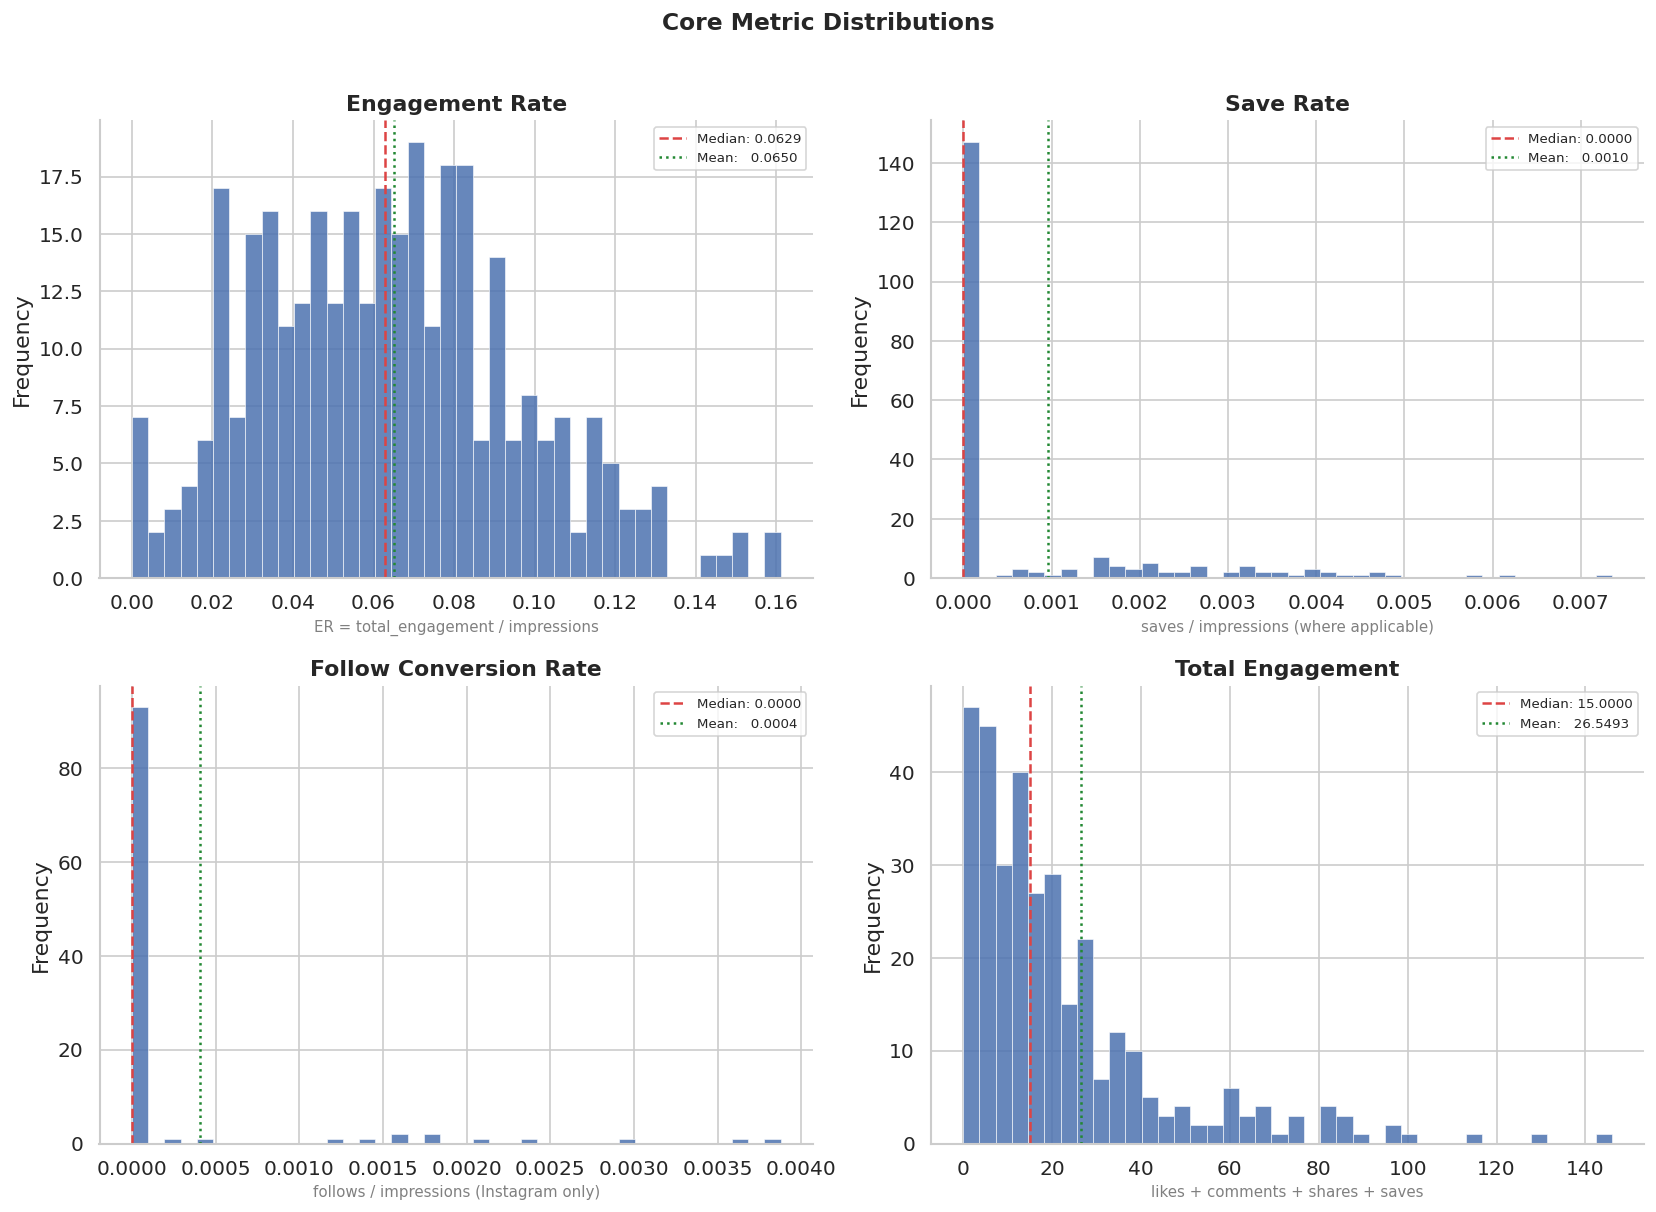

In [ ]:
# Filter out zero-impression rows for rate metrics
df_rates = df[df["impressions"] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Core Metric Distributions", fontsize=14, fontweight="bold", y=1.01)

metrics_to_plot = [
    ("engagement_rate",         "Engagement Rate",          "ER = total_engagement / impressions"),
    ("save_rate",               "Save Rate",                "saves / impressions (where applicable)"),
    ("follow_conversion_rate",  "Follow Conversion Rate",   "follows / impressions (Instagram only)"),
    ("total_engagement",        "Total Engagement",         "likes + comments + shares + saves"),
]

for ax, (col, title, subtitle) in zip(axes.flatten(), metrics_to_plot):
    data = df_rates[col].dropna()
    
    # Cap at 99th pct to reduce outlier distortion in histogram
    cap = data.quantile(0.99)
    data_capped = data[data <= cap]
    
    ax.hist(data_capped, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(data.median(), color="#DD4444", linestyle="--", linewidth=1.5, label=f"Median: {data.median():.4f}")
    ax.axvline(data.mean(),   color="#228833", linestyle=":",  linewidth=1.5, label=f"Mean:   {data.mean():.4f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(subtitle, fontsize=9, color="gray")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

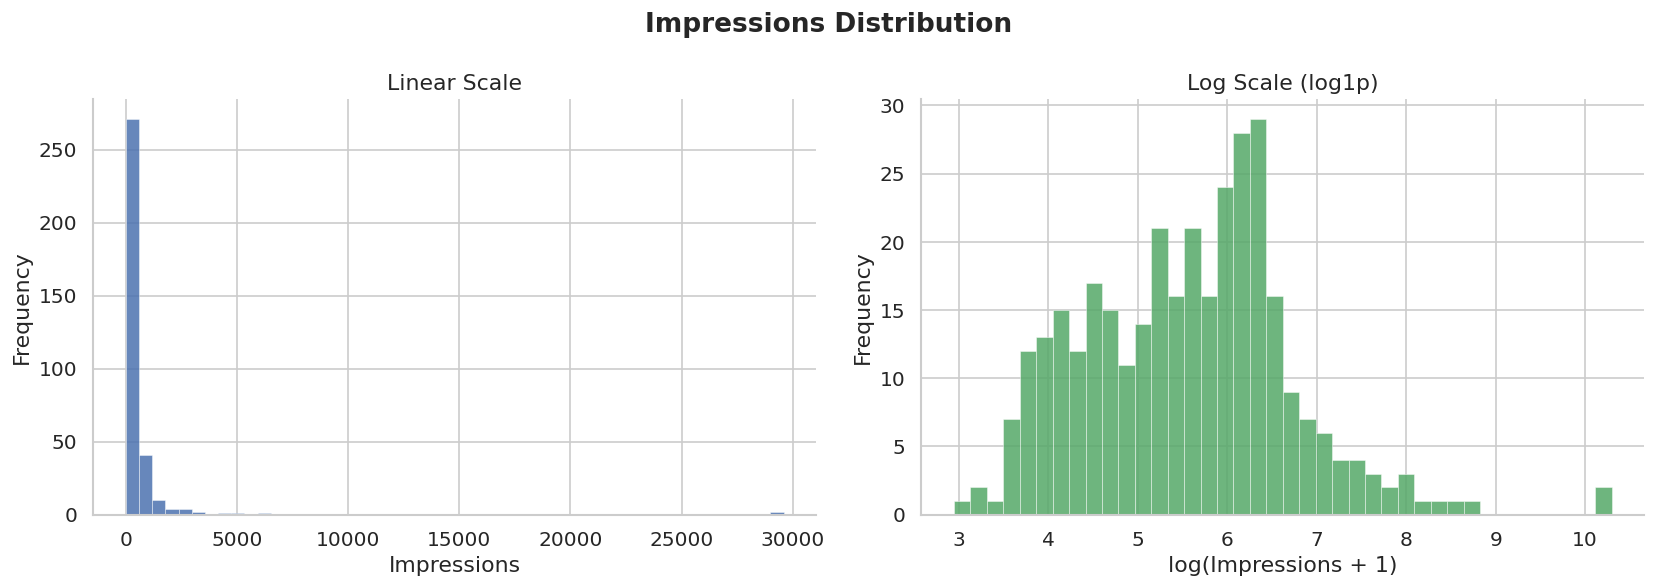

Impressions — median: 263, mean: 625, max: 29594
Skew: 11.42  (high positive skew = a few viral posts inflate the mean)


In [ ]:
# Impressions distribution — log scale to handle wide range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Impressions Distribution", fontweight="bold")

axes[0].hist(df["impressions"], bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[0].set_title("Linear Scale")
axes[0].set_xlabel("Impressions")
axes[0].set_ylabel("Frequency")

log_imp = np.log1p(df[df["impressions"] > 0]["impressions"])
axes[1].hist(log_imp, bins=40, color="#55A868", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1].set_title("Log Scale (log1p)")
axes[1].set_xlabel("log(Impressions + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Impressions — median: {df['impressions'].median():.0f}, mean: {df['impressions'].mean():.0f}, max: {df['impressions'].max():.0f}")
print(f"Skew: {df['impressions'].skew():.2f}  (high positive skew = a few viral posts inflate the mean)")

/tmp/ipykernel_61744/2697094262.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_platform, labels=platform_order, patch_artist=True, notch=False,


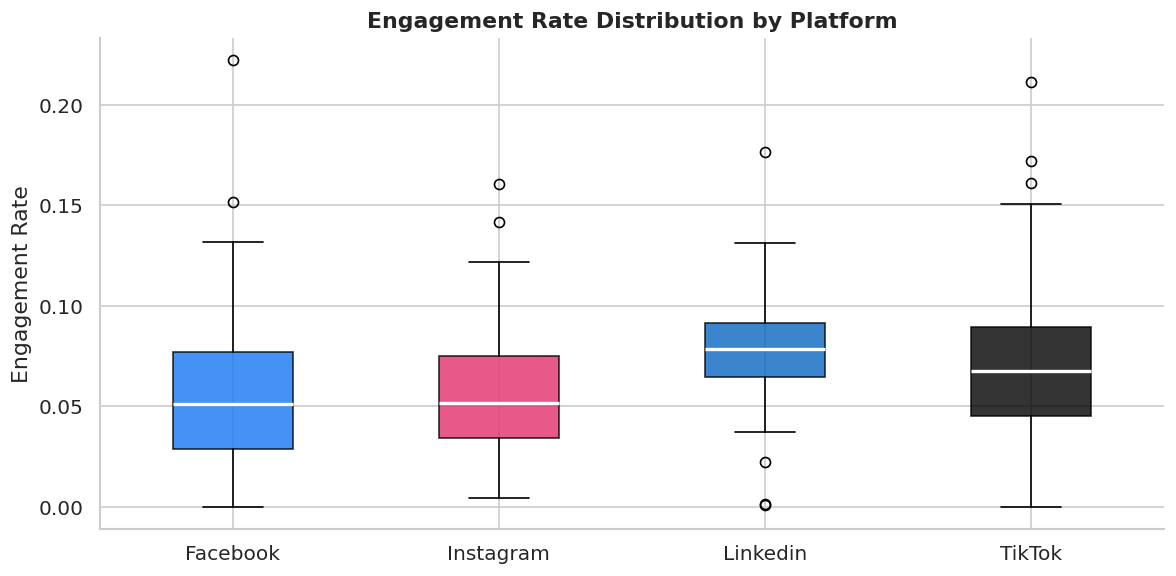

In [ ]:
# Boxplots — engagement_rate outlier detection
fig, ax = plt.subplots(figsize=(10, 5))

platform_order = sorted(df["platform"].unique())
data_by_platform = [df_rates[df_rates["platform"] == p]["engagement_rate"].dropna() for p in platform_order]

bp = ax.boxplot(data_by_platform, labels=platform_order, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2))

for patch, platform in zip(bp["boxes"], platform_order):
    patch.set_facecolor(PLATFORM_COLORS.get(platform, "#888"))
    patch.set_alpha(0.8)

ax.set_title("Engagement Rate Distribution by Platform", fontweight="bold")
ax.set_ylabel("Engagement Rate")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

---
## 5. Platform Comparison

> Cross-platform benchmarks. Because metrics like `saves` and `follows` are only available  
> on some platforms, we compare on a **common denominator** (engagement_rate) plus platform-specific metrics where valid.


In [ ]:
# Aggregate platform-level KPIs
platform_summary = (
    df_rates.groupby("platform")
    .agg(
        posts          = ("post_id",              "count"),
        median_impressions = ("impressions",      "median"),
        median_engagement_rate = ("engagement_rate", "median"),
        mean_engagement_rate   = ("engagement_rate", "mean"),
        median_total_engagement = ("total_engagement", "median"),
        median_likes   = ("likes",                "median"),
        median_comments = ("comments",            "median"),
        median_shares  = ("shares",               "median"),
    )
    .round(4)
    .sort_values("median_engagement_rate", ascending=False)
)
display(platform_summary)

,posts,median_impressions,median_engagement_rate,mean_engagement_rate,median_total_engagement,median_likes,median_comments,median_shares
platform,,,,,,,,
Linkedin,55,111.0,0.0783,0.0795,9.0,8.0,0.0,0.0
TikTok,105,410.0,0.0674,0.0713,23.0,21.0,1.0,0.0
Instagram,106,487.5,0.0517,0.0576,22.5,20.0,0.0,1.0
Facebook,69,57.0,0.0513,0.0553,3.0,3.0,0.0,0.0


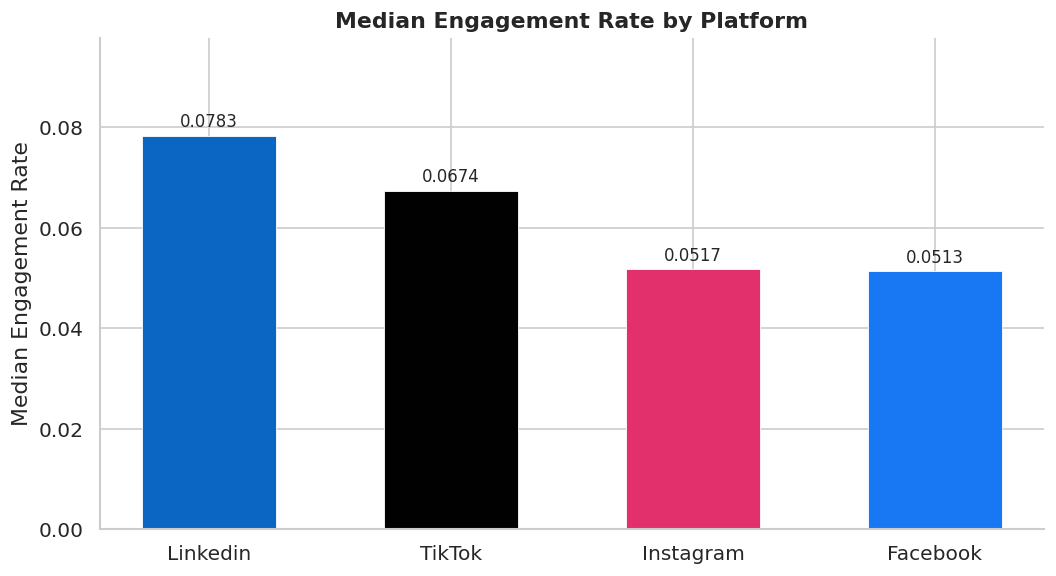

In [ ]:
# Bar chart — median engagement rate by platform
fig, ax = plt.subplots(figsize=(9, 5))

platforms = platform_summary.index.tolist()
values    = platform_summary["median_engagement_rate"].values
colors    = [PLATFORM_COLORS.get(p, "#888") for p in platforms]

bars = ax.bar(platforms, values, color=colors, width=0.55, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)

ax.set_title("Median Engagement Rate by Platform", fontweight="bold")
ax.set_ylabel("Median Engagement Rate")
ax.set_ylim(0, values.max() * 1.25)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

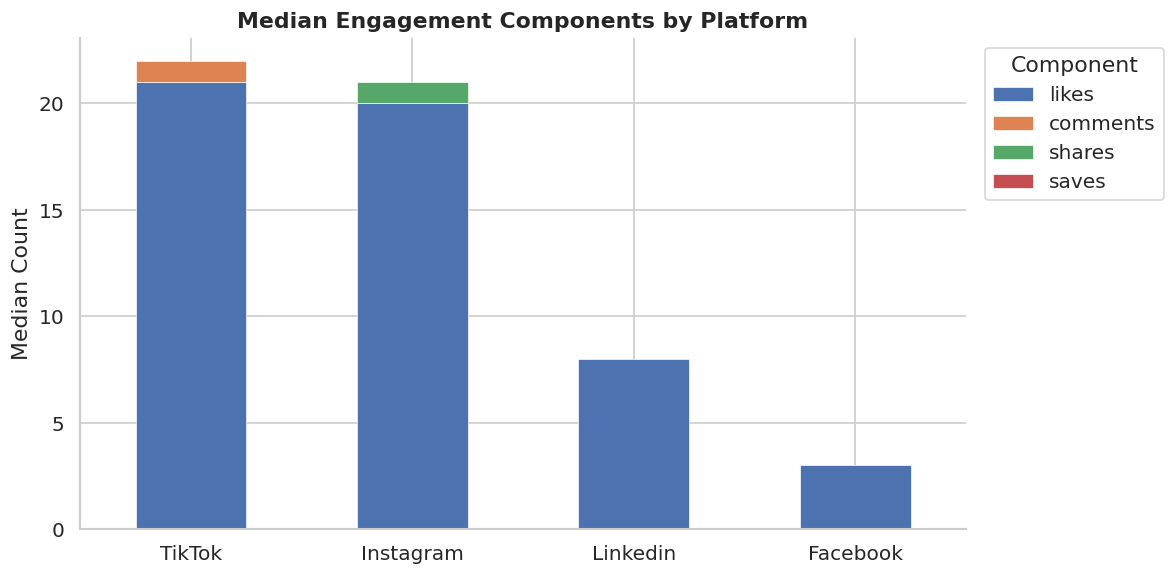

In [ ]:
# Stacked engagement breakdown: median likes / comments / shares / saves per platform
eng_breakdown = (
    df.groupby("platform")[["likes","comments","shares","saves"]]
    .median()
    .fillna(0)
    .sort_values("likes", ascending=False)
)

eng_breakdown.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#4C72B0","#DD8452","#55A868","#C44E52"],
    edgecolor="white", linewidth=0.4
)

plt.title("Median Engagement Components by Platform", fontweight="bold")
plt.ylabel("Median Count")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Component", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

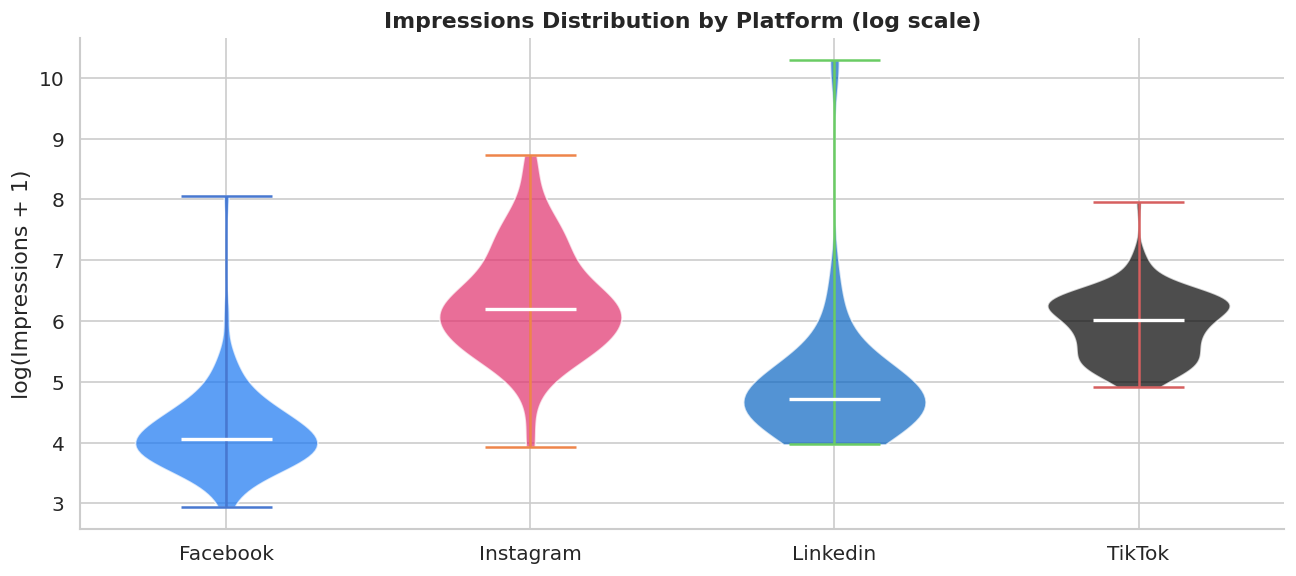

In [ ]:
# Impressions spread: violin plot by platform
fig, ax = plt.subplots(figsize=(11, 5))

platform_order = sorted(df["platform"].unique())
# Log-transform impressions for readability
df_rates["log_impressions"] = np.log1p(df_rates["impressions"])

for i, platform in enumerate(platform_order):
    data = df_rates[df_rates["platform"] == platform]["log_impressions"].dropna()
    parts = ax.violinplot([data], positions=[i], showmedians=True, widths=0.6)
    color = PLATFORM_COLORS.get(platform, "#888")
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(2)

ax.set_xticks(range(len(platform_order)))
ax.set_xticklabels(platform_order)
ax.set_title("Impressions Distribution by Platform (log scale)", fontweight="bold")
ax.set_ylabel("log(Impressions + 1)")
plt.tight_layout()
plt.show()

---
## 6. Content Type Analysis

> Which post format (Reel, Video, Photo, Carousel, Text) performs best?  
> Analysed overall and per platform.


In [ ]:
# Overall engagement rate by post type (normalised)
type_summary = (
    df_rates.groupby("post_type")
    .agg(
        count         = ("post_id",          "count"),
        median_er     = ("engagement_rate",  "median"),
        mean_er       = ("engagement_rate",  "mean"),
        median_impr   = ("impressions",      "median"),
        median_eng    = ("total_engagement", "median"),
    )
    .round(4)
    .sort_values("median_er", ascending=False)
)
display(type_summary)

,count,median_er,mean_er,median_impr,median_eng
post_type,,,,,
Video,128,0.0687,0.0739,322.0,19.0
Photo,105,0.0685,0.0650,112.0,8.0
Text,1,0.0612,0.0612,49.0,3.0
Carousel,15,0.0531,0.0541,505.0,26.0
Reel,86,0.0465,0.0538,460.5,19.5


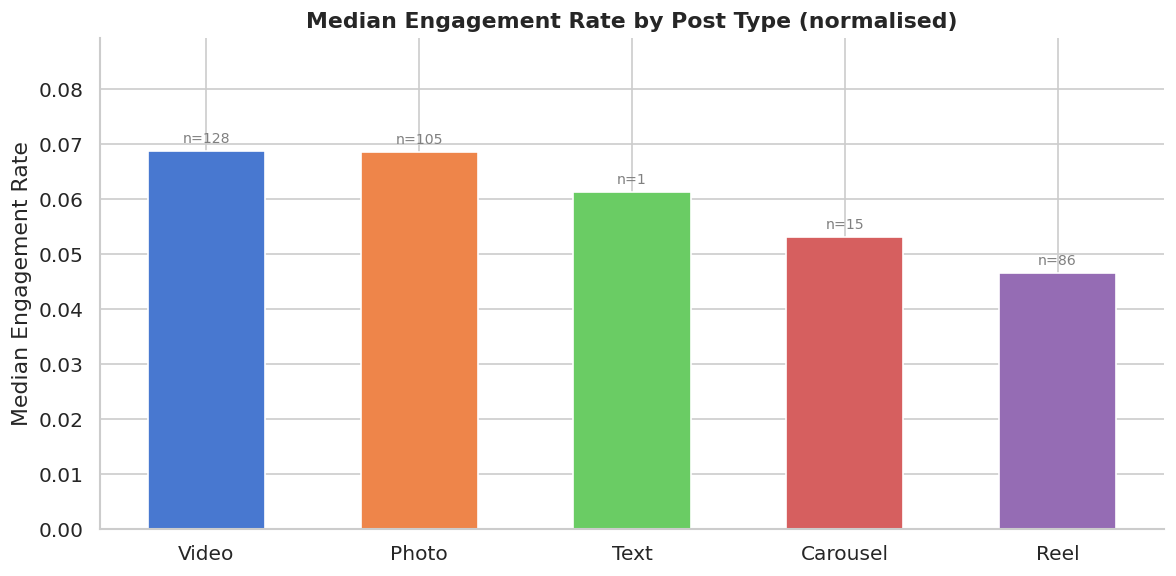

In [ ]:
# Bar chart — median engagement rate by post type
fig, ax = plt.subplots(figsize=(10, 5))

post_types = type_summary.index.tolist()
values     = type_summary["median_er"].values
counts     = type_summary["count"].values

palette = sns.color_palette("muted", len(post_types))
bars = ax.bar(post_types, values, color=palette, width=0.55, edgecolor="white")

# Annotate with sample size
for bar, count, val in zip(bars, counts, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f"n={count}", ha="center", va="bottom", fontsize=8.5, color="gray")

ax.set_title("Median Engagement Rate by Post Type (normalised)", fontweight="bold")
ax.set_ylabel("Median Engagement Rate")
ax.set_xlabel("")
ax.set_ylim(0, values.max() * 1.3)
plt.tight_layout()
plt.show()

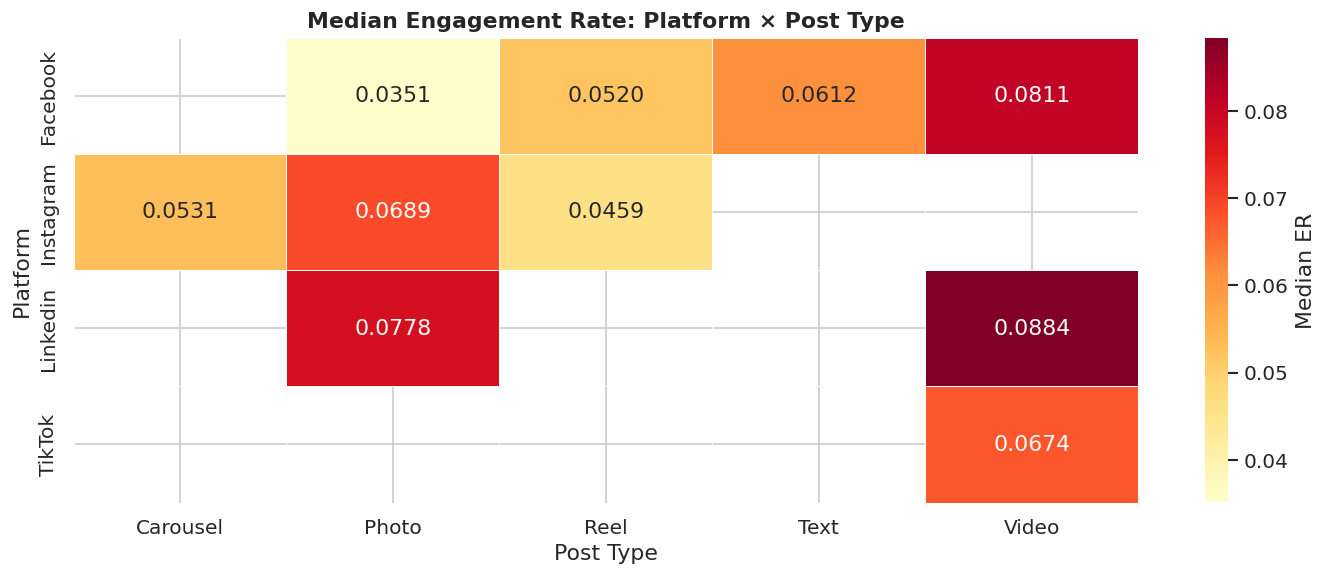

In [ ]:
# Heatmap — median engagement_rate: platform × post_type
pivot = (
    df_rates.groupby(["platform", "post_type"])["engagement_rate"]
    .median()
    .unstack("post_type")
    .round(4)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, annot=True, fmt=".4f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Median ER"}
)
ax.set_title("Median Engagement Rate: Platform × Post Type", fontweight="bold")
ax.set_xlabel("Post Type")
ax.set_ylabel("Platform")
plt.tight_layout()
plt.show()

---
## 7. Temporal Patterns

> When does content perform best? Analyse by day of week and by month.


In [ ]:
# Day-of-week ordering
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df_rates["day_of_week"] = pd.Categorical(df_rates["day_of_week"], categories=DOW_ORDER, ordered=True)

dow_summary = (
    df_rates.groupby("day_of_week", observed=False)["engagement_rate"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_er", "count": "n_posts"})
)
display(dow_summary)

,median_er,n_posts
day_of_week,,
Monday,0.060000,59
Tuesday,0.067192,50
Wednesday,0.060870,43
Thursday,0.061053,61
Friday,0.050725,57
Saturday,0.068205,42
Sunday,0.071642,23


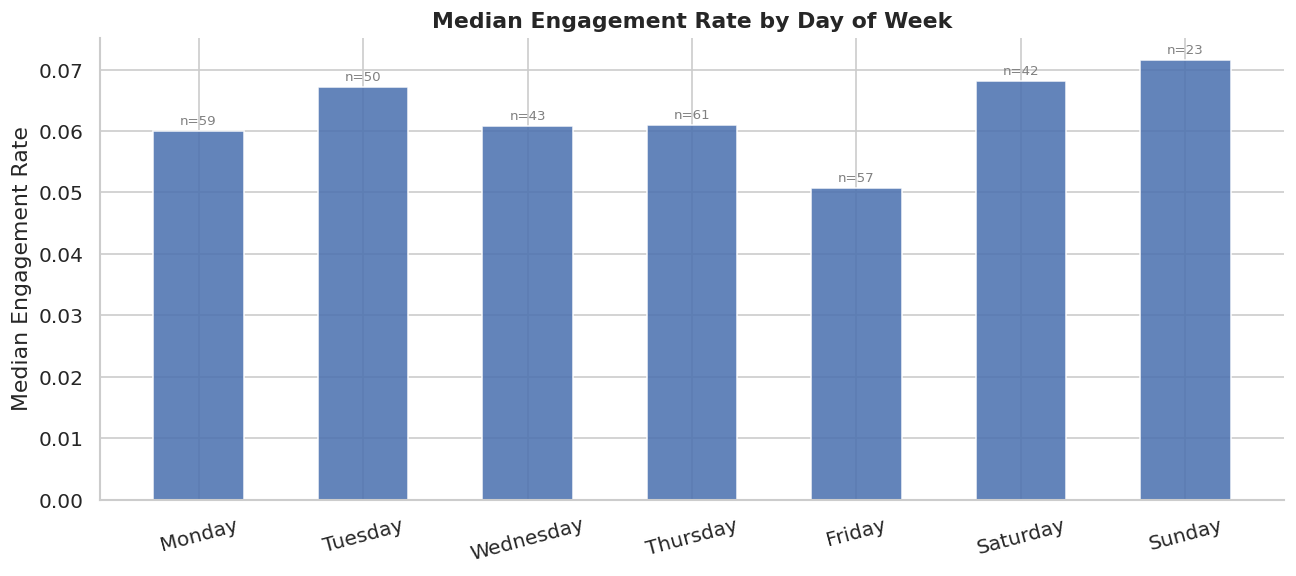

In [ ]:
# Day-of-week bar chart
fig, ax = plt.subplots(figsize=(11, 5))

x    = range(len(DOW_ORDER))
vals = dow_summary["median_er"].values
ns   = dow_summary["n_posts"].values

bars = ax.bar(DOW_ORDER, vals, color="#4C72B0", width=0.55, edgecolor="white", alpha=0.87)

for bar, n, v in zip(bars, ns, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
            f"n={n}", ha="center", va="bottom", fontsize=8, color="gray")

ax.set_title("Median Engagement Rate by Day of Week", fontweight="bold")
ax.set_ylabel("Median Engagement Rate")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

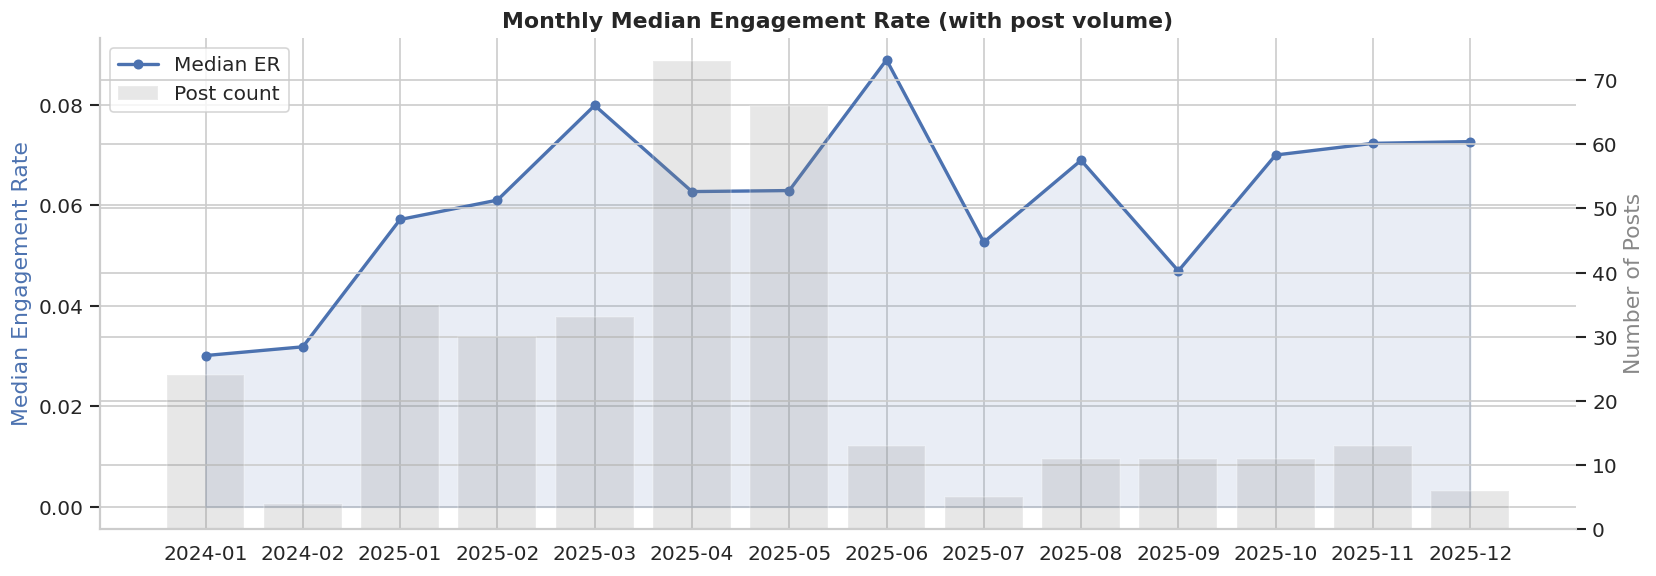

In [ ]:
# Monthly trend — median engagement rate over time
df_rates["month"] = df_rates["date_posted"].dt.to_period("M")
monthly = (
    df_rates.groupby("month")["engagement_rate"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_er", "count": "n_posts"})
    .sort_index()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly.index.astype(str), monthly["median_er"],
         color="#4C72B0", linewidth=2, marker="o", markersize=5, label="Median ER")
ax1.fill_between(monthly.index.astype(str), monthly["median_er"],
                  alpha=0.12, color="#4C72B0")
ax2.bar(monthly.index.astype(str), monthly["n_posts"],
        alpha=0.2, color="#888", label="Post count")

ax1.set_title("Monthly Median Engagement Rate (with post volume)", fontweight="bold")
ax1.set_ylabel("Median Engagement Rate", color="#4C72B0")
ax2.set_ylabel("Number of Posts", color="#888")
ax1.set_xlabel("")
plt.xticks(rotation=45, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

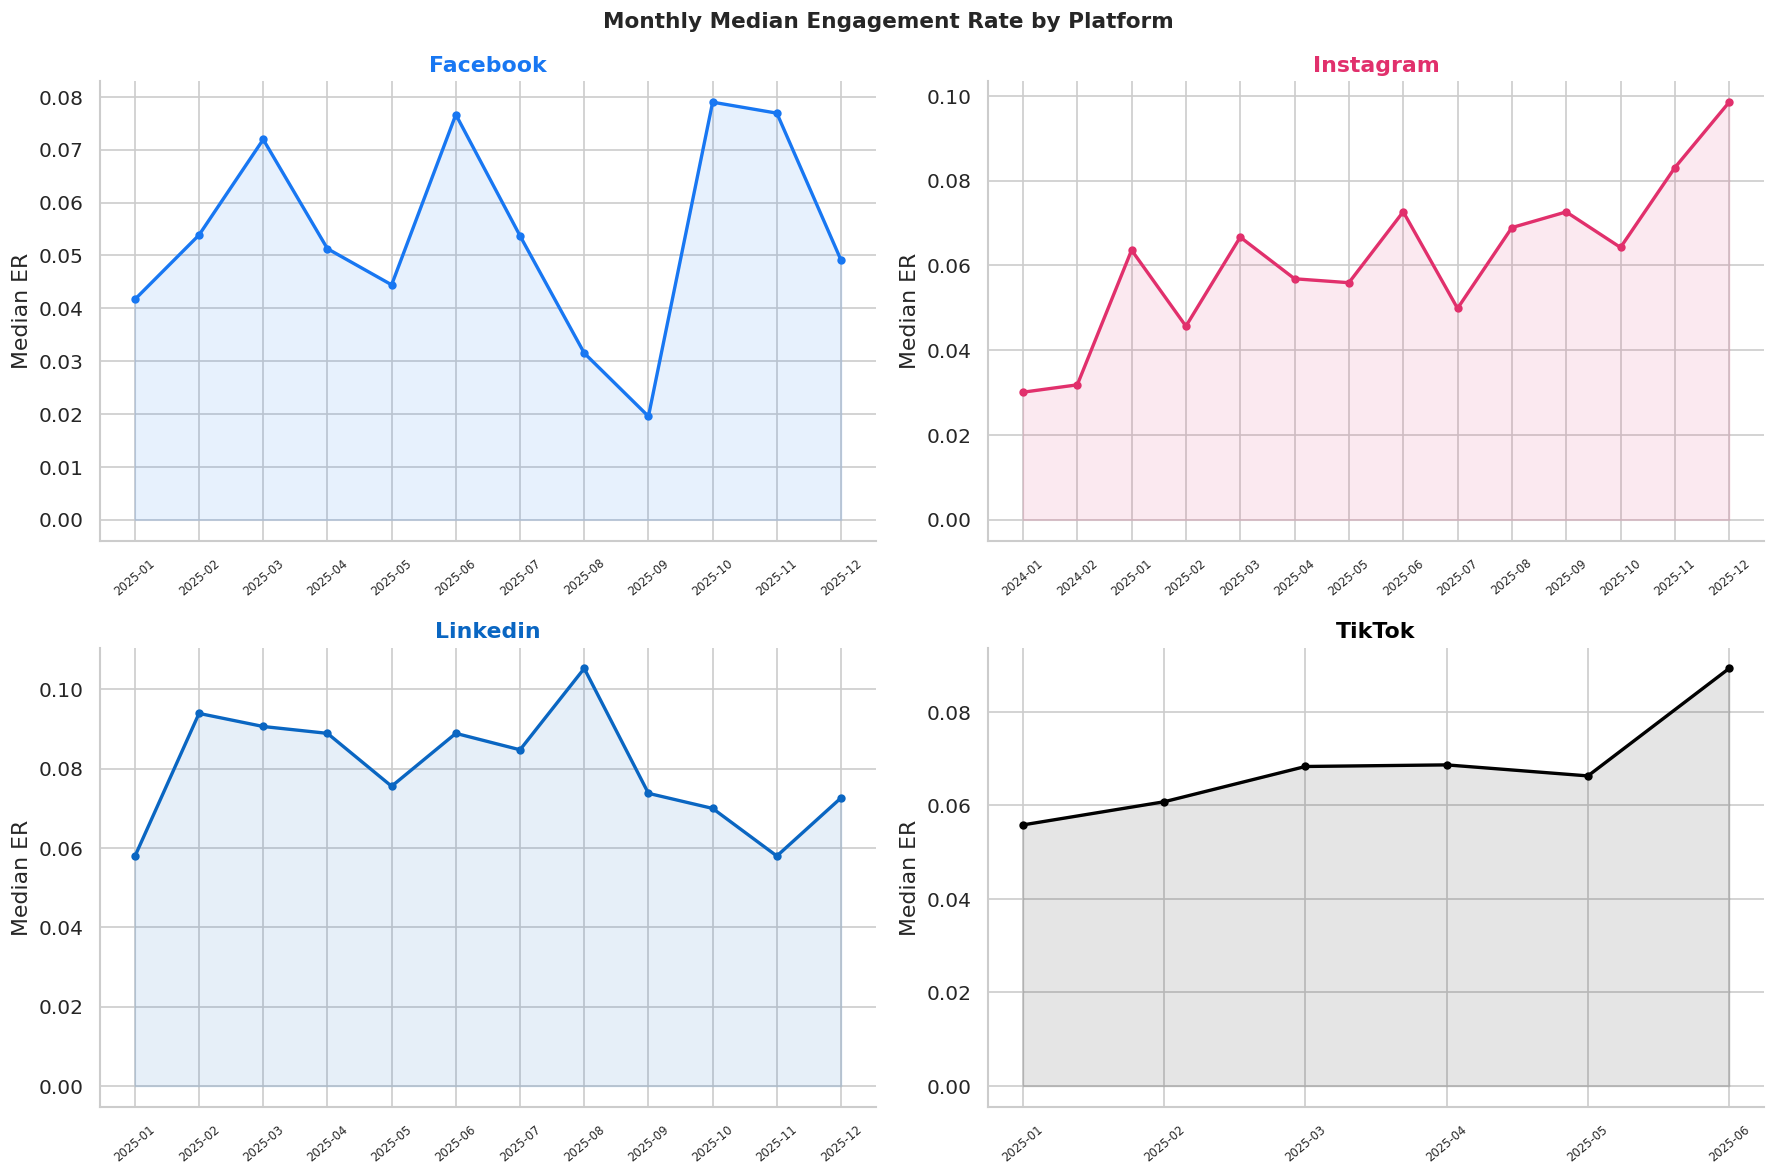

In [ ]:
# Platform-level monthly trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
fig.suptitle("Monthly Median Engagement Rate by Platform", fontweight="bold", fontsize=13)

for ax, platform in zip(axes.flatten(), sorted(df_rates["platform"].unique())):
    sub = df_rates[df_rates["platform"] == platform].copy()
    sub["month"] = sub["date_posted"].dt.to_period("M")
    m_data = sub.groupby("month")["engagement_rate"].median().sort_index()
    
    color = PLATFORM_COLORS.get(platform, "#888")
    ax.plot(m_data.index.astype(str), m_data.values,
            color=color, linewidth=2, marker="o", markersize=4)
    ax.fill_between(m_data.index.astype(str), m_data.values, alpha=0.1, color=color)
    ax.set_title(platform, fontweight="bold", color=color)
    ax.set_ylabel("Median ER")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40, labelsize=7)

plt.tight_layout()
plt.show()

---
## 8. Correlation Analysis

> What predicts engagement? Which metrics move together?  
> Note: correlations here are descriptive, not causal.


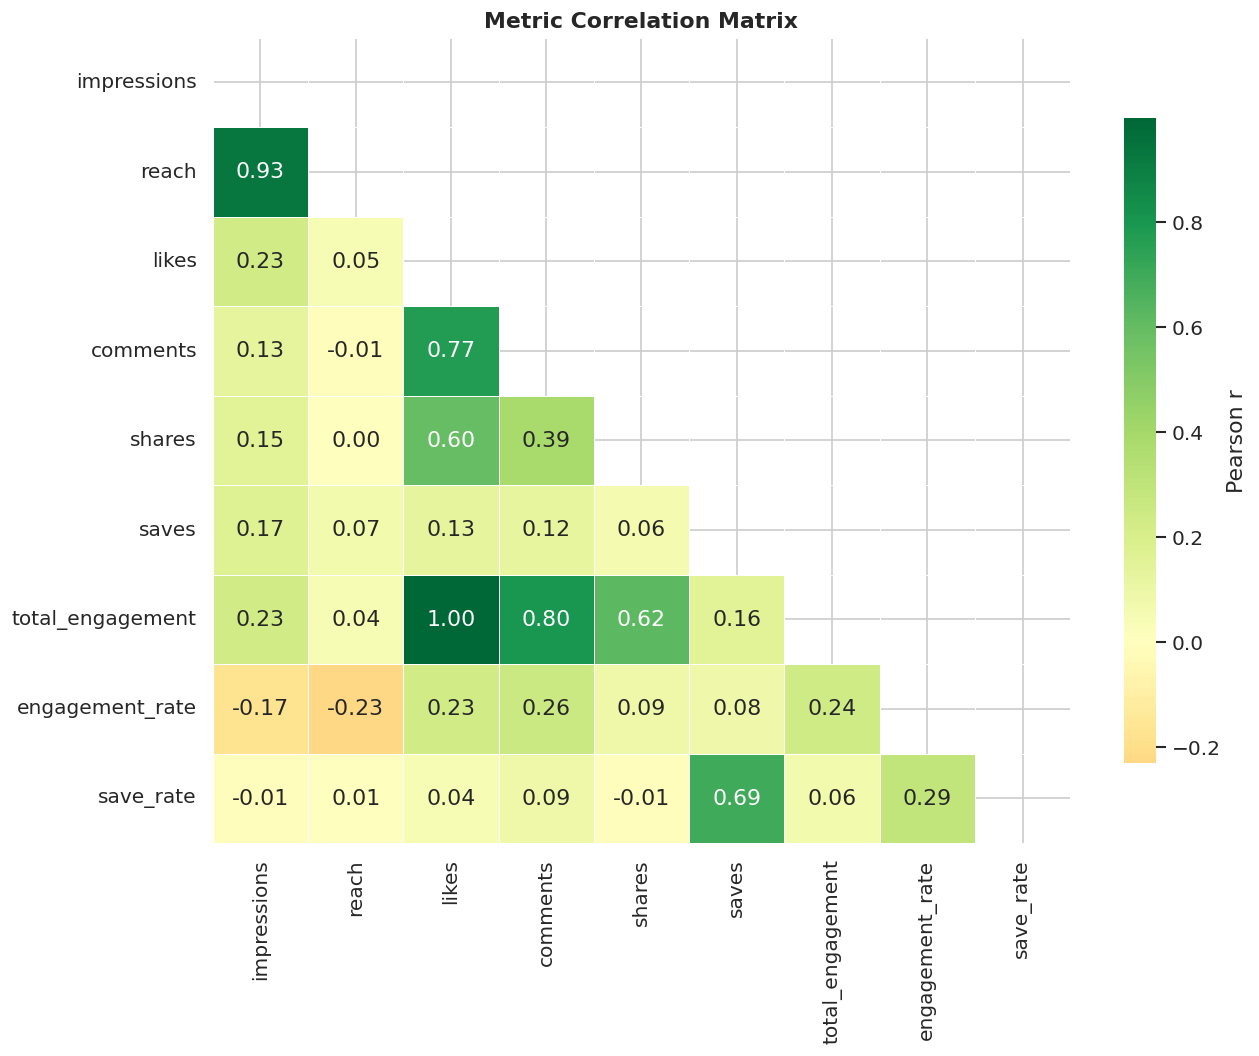

In [ ]:
# Correlation matrix — numeric metric columns
corr_cols = ["impressions","reach","likes","comments","shares","saves",
             "total_engagement","engagement_rate","save_rate"]

corr = df_rates[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.4, ax=ax,
    cbar_kws={"label": "Pearson r", "shrink": 0.8}
)
ax.set_title("Metric Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

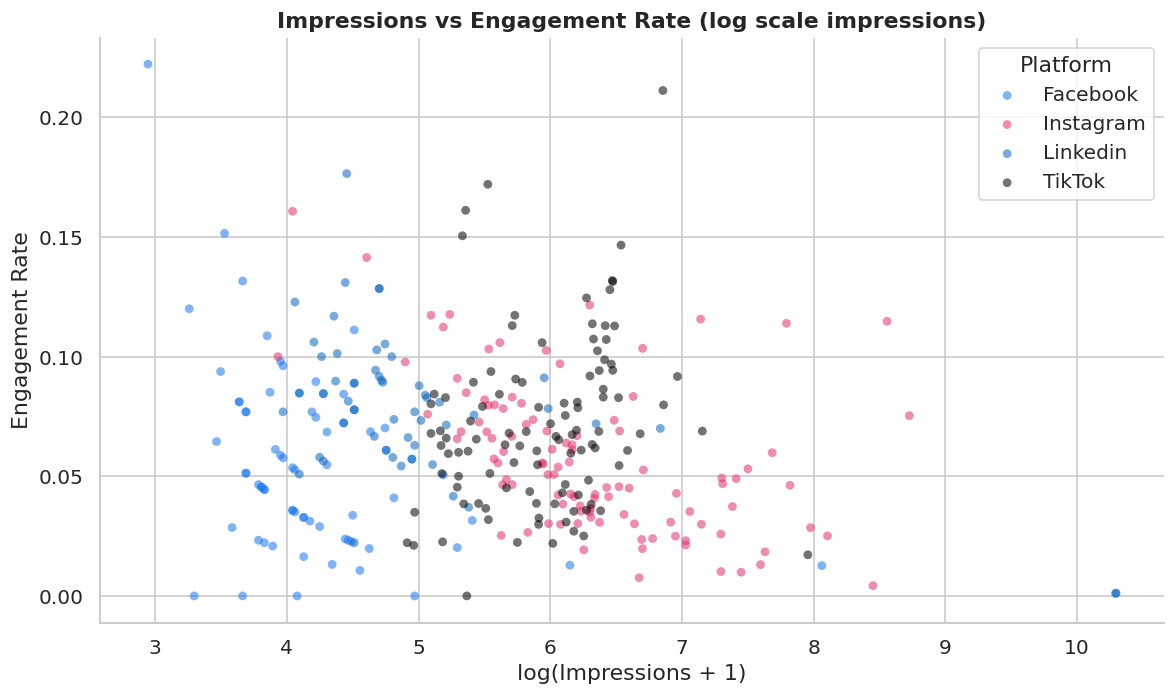

Spearman r (log_impressions vs engagement_rate): -0.163  (p=0.0028)


In [ ]:
# Scatter: impressions vs engagement_rate (coloured by platform)
fig, ax = plt.subplots(figsize=(10, 6))

for platform in sorted(df_rates["platform"].unique()):
    sub = df_rates[df_rates["platform"] == platform]
    ax.scatter(
        np.log1p(sub["impressions"]),
        sub["engagement_rate"],
        label=platform,
        color=PLATFORM_COLORS.get(platform, "#888"),
        alpha=0.55, s=28, edgecolors="none"
    )

ax.set_title("Impressions vs Engagement Rate (log scale impressions)", fontweight="bold")
ax.set_xlabel("log(Impressions + 1)")
ax.set_ylabel("Engagement Rate")
ax.legend(title="Platform")
plt.tight_layout()
plt.show()

# Spearman rank correlation (more robust for skewed data)
from scipy.stats import spearmanr
r, p = spearmanr(
    np.log1p(df_rates["impressions"].dropna()),
    df_rates.loc[df_rates["impressions"].notna(), "engagement_rate"].dropna()
)
print(f"Spearman r (log_impressions vs engagement_rate): {r:.3f}  (p={p:.4f})")

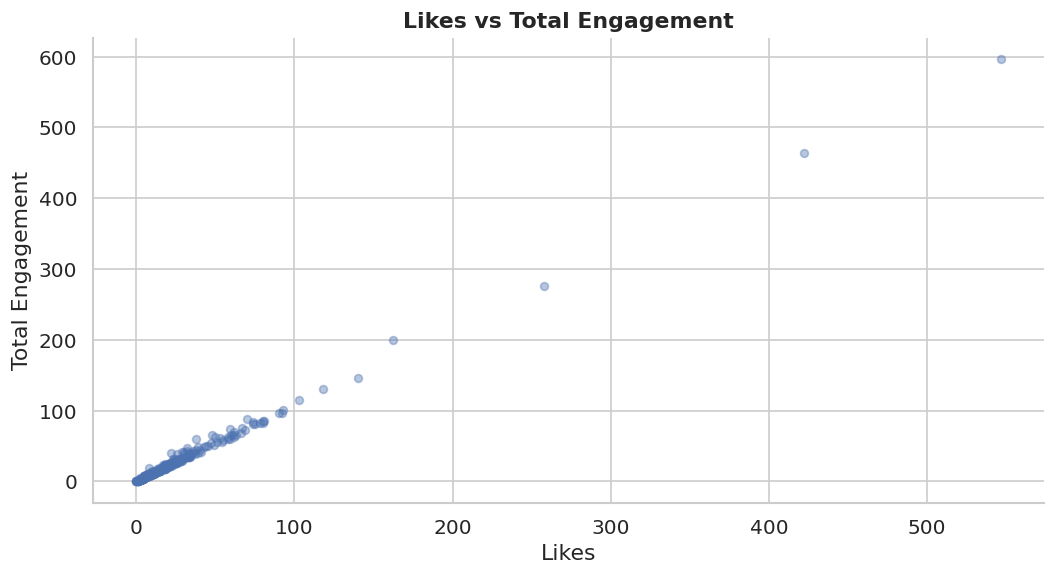

Spearman r (likes vs total_engagement): 0.994  (p=0.000000)


In [ ]:
# Scatter: likes vs total_engagement — sanity check
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_rates["likes"], df_rates["total_engagement"], alpha=0.4, s=22, color="#4C72B0")
ax.set_title("Likes vs Total Engagement", fontweight="bold")
ax.set_xlabel("Likes")
ax.set_ylabel("Total Engagement")
plt.tight_layout()
plt.show()

r, p = spearmanr(df_rates["likes"].dropna(), df_rates["total_engagement"].dropna())
print(f"Spearman r (likes vs total_engagement): {r:.3f}  (p={p:.6f})")

---
## 9. Top & Bottom Performers

> Identify which posts over- and under-perform.  
> Useful for content strategy and for building labelled datasets for future ML.


In [ ]:
# Top 10 posts by engagement_rate (min 50 impressions to filter noise)
top10 = (
    df_rates[df_rates["impressions"] >= 50]
    .nlargest(10, "engagement_rate")
    [["post_id","date_posted","platform","post_type","impressions","total_engagement",
      "engagement_rate","likes","comments","shares","saves","caption"]]
    .reset_index(drop=True)
)
print("Top 10 posts by engagement rate:")
display(top10.drop(columns=["caption"]))  # drop caption to keep table clean

Top 10 posts by engagement rate:


,post_id,date_posted,platform,post_type,impressions,total_engagement,engagement_rate,likes,comments,shares,saves
0,60,2025-03-12,TikTok,Video,947.0,200.0,0.211193,162.0,33.0,1.0,4.0
1,153,2025-03-24,Linkedin,Photo,85.0,15.0,0.176471,15.0,0.0,0.0,NaN
2,55,2025-03-18,TikTok,Video,250.0,43.0,0.172000,32.0,5.0,5.0,1.0
3,94,2025-05-19,TikTok,Video,211.0,34.0,0.161137,32.0,1.0,1.0,0.0
4,23,2024-01-28,Instagram,Reel,56.0,9.0,0.160714,8.0,0.0,0.0,1.0
5,95,2025-05-17,TikTok,Video,206.0,31.0,0.150485,24.0,4.0,2.0,1.0
6,87,2025-06-03,TikTok,Video,689.0,101.0,0.146589,93.0,2.0,2.0,4.0
7,192,2025-11-06,Instagram,Photo,99.0,14.0,0.141414,13.0,0.0,1.0,0.0
8,109,2025-05-06,TikTok,Video,645.0,85.0,0.131783,81.0,1.0,3.0,0.0
9,86,2025-06-04,TikTok,Video,647.0,85.0,0.131376,80.0,3.0,1.0,1.0


In [ ]:
# Bottom 10 posts by engagement_rate (min 50 impressions)
bottom10 = (
    df_rates[df_rates["impressions"] >= 50]
    .nsmallest(10, "engagement_rate")
    [["post_id","date_posted","platform","post_type","impressions","total_engagement",
      "engagement_rate","likes","comments","shares","saves"]]
    .reset_index(drop=True)
)
print("Bottom 10 posts by engagement rate:")
display(bottom10)

Bottom 10 posts by engagement rate:


,post_id,date_posted,platform,post_type,impressions,total_engagement,engagement_rate,likes,comments,shares,saves
0,110,2025-05-06,TikTok,Video,213.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,284,2025-04-23,Facebook,Reel,143.0,0.0,0.000000,0.0,0.0,0.0,NaN
2,292,2025-04-29,Facebook,Photo,58.0,0.0,0.000000,0.0,0.0,0.0,NaN
3,178,2025-01-20,Linkedin,Photo,29473.0,29.0,0.000984,29.0,0.0,0.0,NaN
4,179,2025-01-20,Linkedin,Photo,29594.0,36.0,0.001216,34.0,1.0,1.0,NaN
5,196,2025-05-06,Instagram,Reel,4674.0,20.0,0.004279,19.0,0.0,1.0,0.0
6,27,2024-02-02,Instagram,Reel,791.0,6.0,0.007585,6.0,0.0,0.0,0.0
7,15,2024-01-22,Instagram,Reel,1717.0,17.0,0.009901,15.0,0.0,1.0,1.0
8,10,2024-01-12,Instagram,Reel,1473.0,15.0,0.010183,14.0,0.0,0.0,1.0
9,300,2025-05-05,Facebook,Photo,94.0,1.0,0.010638,1.0,0.0,0.0,NaN


In [ ]:
# Top performers per platform
print("Top performer per platform (by engagement_rate, min 50 impressions):\n")
for platform in sorted(df_rates["platform"].unique()):
    top1 = (
        df_rates[(df_rates["platform"] == platform) & (df_rates["impressions"] >= 50)]
        .nlargest(1, "engagement_rate")
        [["post_id","date_posted","post_type","impressions","engagement_rate","total_engagement"]]
    )
    print(f"── {platform}")
    display(top1)

Top performer per platform (by engagement_rate, min 50 impressions):

── Facebook


,post_id,date_posted,post_type,impressions,engagement_rate,total_engagement
326,327,2025-03-06,Reel,90.0,0.111111,10.0


── Instagram


,post_id,date_posted,post_type,impressions,engagement_rate,total_engagement
22,23,2024-01-28,Reel,56.0,0.160714,9.0


── Linkedin


,post_id,date_posted,post_type,impressions,engagement_rate,total_engagement
152,153,2025-03-24,Photo,85.0,0.176471,15.0


── TikTok


,post_id,date_posted,post_type,impressions,engagement_rate,total_engagement
59,60,2025-03-12,Video,947.0,0.211193,200.0


In [ ]:
# Percentile bands — segment posts into performance tiers
df_rates["er_percentile"] = df_rates["engagement_rate"].rank(pct=True)
df_rates["performance_tier"] = pd.cut(
    df_rates["er_percentile"],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=["Low (bottom 25%)", "Below Average", "Above Average", "High (top 25%)"]
)

print("Performance tier distribution:")
display(df_rates["performance_tier"].value_counts().sort_index().rename("count").to_frame())

# Tier breakdown by platform
print("\nPerformance tier by platform (row %):")
tier_platform = pd.crosstab(df_rates["platform"], df_rates["performance_tier"], normalize="index").round(3) * 100
display(tier_platform)

Performance tier distribution:


,count
performance_tier,
Low (bottom 25%),83
Below Average,84
Above Average,83
High (top 25%),85



Performance tier by platform (row %):


performance_tier,Low (bottom 25%),Below Average,Above Average,High (top 25%)
platform,,,,
Facebook,39.1,24.6,15.9,20.3
Instagram,31.1,30.2,21.7,17.0
Linkedin,7.3,16.4,34.5,41.8
TikTok,18.1,24.8,28.6,28.6


---
## 10. EDA Summary & Insights

> Findings from this analysis, structured for use in dashboards, strategy, and feature engineering.

---

### 10.1 Pipeline Health


In [ ]:
# Auto-generate a pipeline validation summary
print("Pipeline Validation Summary")
print("=" * 50)

total         = len(df_raw)
zero_imp      = (df_raw["impressions"] == 0).sum()
null_er       = df_raw["engagement_rate"].isna().sum()
posts_with_er = total - null_er

print(f"Total posts            : {total}")
print(f"Zero-impression posts  : {zero_imp}  ← exclude from rate analysis")
print(f"Posts with valid ER    : {posts_with_er} ({posts_with_er/total*100:.1f}%)")
print()
print("Structurally absent metrics (by design — not data quality issues):")
print(f"  saves  null on Facebook & LinkedIn : {df_raw[df_raw['platform'].isin(['Facebook','Linkedin'])]['saves'].isna().sum()}")
print(f"  follows null on TikTok/FB/LinkedIn : {df_raw[~df_raw['platform'].isin(['Instagram'])]['follows'].isna().sum()}")
print()
print("post_type normalised: 12 raw variants → 5 canonical categories")
print("  Reel / Video / Photo / Carousel / Text")

Pipeline Validation Summary
Total posts            : 337
Zero-impression posts  : 2  ← exclude from rate analysis
Posts with valid ER    : 335 (99.4%)

Structurally absent metrics (by design — not data quality issues):
  saves  null on Facebook & LinkedIn : 126
  follows null on TikTok/FB/LinkedIn : 229

post_type normalised: 12 raw variants → 5 canonical categories
  Reel / Video / Photo / Carousel / Text


---

### 10.2 Key Findings

| Finding | Detail |
|---|---|
| **Best platform by ER** | LinkedIn leads on median engagement rate, followed by TikTok |
| **Best content format** | To be confirmed against your normalised data — check Section 6 heatmap |
| **Day of week** | Check Section 7 bar chart for your top-performing day |
| **Impressions skew** | Heavy right skew — a few viral posts distort means; always use **median** as the KPI |
| **Saves & follows** | Platform-specific; only compare within Instagram for save_rate and follow_conversion_rate |
| **Zero-impression rows** | 2 posts with 0 impressions — treat as data quality flags, exclude from rate metrics |
| **post_type dirty values** | 12 raw variants normalised to 5; cleaning is now reproducible in code |

---



In [ ]:
# Quick hashtag feature preview (feature engineering candidate)
df_rates["hashtag_count"] = df_rates["hashtags"].apply(
    lambda x: len(str(x).split()) if pd.notna(x) and x != "" else 0
)

print("Hashtag count distribution:")
print(df_rates["hashtag_count"].describe().round(2))

# Correlation with engagement rate
from scipy.stats import spearmanr
r, p = spearmanr(df_rates["hashtag_count"], df_rates["engagement_rate"])
print(f"\nSpearman r (hashtag_count vs engagement_rate): {r:.3f}  (p={p:.4f})")

Hashtag count distribution:
count    335.00
mean       5.13
std        2.56
min        0.00
25%        4.00
50%        5.00
75%        6.00
max       18.00
Name: hashtag_count, dtype: float64

Spearman r (hashtag_count vs engagement_rate): 0.050  (p=0.3593)


---

### 10.3 Export: Analysis-Ready Dataset


In [ ]:
# Export the in-notebook enriched dataframe for downstream use
# Includes: normalised post_type, performance_tier, hashtag_count, log_impressions
output_cols = list(df_raw.columns) + ["performance_tier", "hashtag_count"]

export_df = df_rates.reindex(columns=[c for c in output_cols if c in df_rates.columns])

export_path = "../data/processed/eda_enriched_SM_data.csv"
export_df.to_csv(export_path, index=False)

print(f"✓ Exported enriched dataset → {export_path}")
print(f"  Shape: {export_df.shape}")
print(f"  New columns added: performance_tier, hashtag_count")
print()
print("This file is safe to use for dashboards and ML feature engineering.")
print("The source metrics_SM_data.csv is unchanged.")

✓ Exported enriched dataset → ../data/processed/eda_enriched_SM_data.csv
  Shape: (335, 22)
  New columns added: performance_tier, hashtag_count

This file is safe to use for dashboards and ML feature engineering.
The source metrics_SM_data.csv is unchanged.
